# Tema 2 IA 




In [19]:
import sys
!{sys.executable} -m pip install numpy pandas Pillow matplotlib.pyplot
!{sys.executable} -m pip install matplotlib torch torchvision
!{sys.executable} -m pip install scikit-learn

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Setup

In [20]:
!pip uninstall -y torch torchvision

In [21]:
import sys
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import sys
!{sys.executable} -m pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using ca

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os, json, time, random, math, copy
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.metrics import (f1_score, confusion_matrix, classification_report, accuracy_score)

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.5.1+cu121
CUDA Available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configurare



In [ ]:

DATASET = "emotions"        

CFG = {
    "skin": {
        "name": "Vai de pielea mea",
        "root": "./vai-de-pielea-mea",
        "num_classes": 7,
   
        "class_names": ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"],
        "mean": [0.7646, 0.5464, 0.5712],
        "std":  [0.1410, 0.1532, 0.1706],
        "img_size_cnn": 112,   
        "img_size_mlp": 64,
        "first_kernel": 5,     
    },
    "emotions": {
        "name": "You're on candid camera",
        "root": "./you-re-on-candid-camera",
        "num_classes": 7,

        "class_names": ["Surprise", "Fear", "Disgust", "Happiness",
                        "Sadness", "Anger", "Neutral"],
        "mean": None, 
        "std":  None,
        "img_size_cnn": 96,
        "img_size_mlp": 64,
        "first_kernel": 3, 
    },
}
cfg = CFG[DATASET]
ROOT = Path(cfg["root"])
NUM_CLASSES = cfg["num_classes"]
CLASS_NAMES = cfg["class_names"]
print("Dataset activ:", cfg["name"], "| clase:", NUM_CLASSES)

RUN_DIR = Path("outputs") / DATASET
RUN_DIR.mkdir(parents=True, exist_ok=True)

Dataset activ: You're on candid camera | clase: 7


## 2. Explorarea arhivei



In [25]:
def print_tree(root, max_depth=3, max_items=8, prefix="", depth=0):
    root = Path(root)
    if depth == 0:
        if not root.exists():
            print("NU EXISTA:", root.resolve())
            print("-> Dezarhiveaza si ajusteaza 'root' in CONFIG.")
            return
        print(root.resolve())
    if depth >= max_depth:
        return
    try:
        items = sorted(root.iterdir())
    except Exception:
        return
    dirs = [i for i in items if i.is_dir()]
    files = [i for i in items if i.is_file()]
    for d in dirs[:max_items]:
        n = sum(1 for _ in d.iterdir()) if d.is_dir() else 0
        print(prefix + "  " + d.name + f"/  ({n} intrari)")
        print_tree(d, max_depth, max_items, prefix + "    ", depth + 1)
    if len(dirs) > max_items:
        print(prefix + f"  ... (+{len(dirs)-max_items} foldere)")
    for f in files[:max_items]:
        print(prefix + "  " + f.name)
    if len(files) > max_items:
        print(prefix + f"  ... (+{len(files)-max_items} fisiere)")

print_tree(ROOT)

C:\Users\miner\Desktop\Tema2 IA\you-re-on-candid-camera
  DATASET/  (2 intrari)
      test/  (7 intrari)
          1/  (329 intrari)
          2/  (74 intrari)
          3/  (160 intrari)
          4/  (1185 intrari)
          5/  (478 intrari)
          6/  (162 intrari)
          7/  (680 intrari)
      train/  (7 intrari)
          1/  (1290 intrari)
          2/  (281 intrari)
          3/  (717 intrari)
          4/  (4772 intrari)
          5/  (1982 intrari)
          6/  (705 intrari)
          7/  (2524 intrari)
  splits/  (4 intrari)
      local_test.csv
      norm_stats.json
      remote_test.csv
      train.csv


## 3. Dataset-uri



In [ ]:
class ImageCSVDataset(Dataset):
    '''Dataset generic peste o lista de (cale_absoluta, tinta).
    Daca has_labels: tinta = eticheta int. Altfel: tinta = id (string).'''
    def __init__(self, items, transform=None, has_labels=True):
        self.items = items
        self.transform = transform
        self.has_labels = has_labels
        if has_labels:
            self.labels = [t for _, t in items]
        else:
            self.ids = [t for _, t in items]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, target = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        if self.has_labels:
            return img, target
        return img, idx 


In [ ]:

if DATASET == "emotions":
    stats = json.loads((ROOT / "splits" / "norm_stats.json").read_text())
    cfg["mean"], cfg["std"] = stats["mean"], stats["std"]
    print("mean/std emotions:", cfg["mean"], cfg["std"])

MEAN, STD = cfg["mean"], cfg["std"]
assert MEAN is not None and STD is not None, "Lipsesc statisticile de normalizare"


mean/std emotions: [0.5752126091262171, 0.4497227663589234, 0.4012869135370431] [0.26532880449272844, 0.24229550144470252, 0.24068486736909714]


In [ ]:
def build_splits(eval_transform):
    '''Returneaza (train_ds, test_ds, remote_ds). Builder specific per dataset.'''
    if DATASET == "skin":
        name2idx = {c: i for i, c in enumerate(CLASS_NAMES)}

        def items(csv, folder, labeled=True):
            df = pd.read_csv(ROOT / csv)
            out = []
            for _, r in df.iterrows():
                p = str(ROOT / folder / r["imagine"])
                if labeled:
                    out.append((p, name2idx[r["diagnostic"]]))
                else:
                    out.append((p, r["imagine"]))
            return out

        train_ds = ImageCSVDataset(items("train.csv", "train"), eval_transform)
        test_ds  = ImageCSVDataset(items("test.csv", "test"), eval_transform)
        remote_ds = ImageCSVDataset(
            items("kaggle_test.csv", "kaggle_test", labeled=False),
            eval_transform, has_labels=False)

    else: 
        def items_csv(csv, label_offset=1):
            df = pd.read_csv(ROOT / csv)

            return [(str(ROOT / r["path"]), int(r["label"]) - label_offset)
                    for _, r in df.iterrows()]

        train_ds = ImageCSVDataset(items_csv("splits/train.csv"), eval_transform)
        test_ds  = ImageCSVDataset(items_csv("splits/local_test.csv"),
                                   eval_transform)
       
        test_index = {f.name: str(f)
                      for f in (ROOT / "DATASET" / "test").rglob("*.jpg")}
        df_r = pd.read_csv(ROOT / "splits" / "remote_test.csv")
        remote_items = [(test_index[i], i) for i in df_r["id"]]
        remote_ds = ImageCSVDataset(remote_items, eval_transform,
                                    has_labels=False)

    return train_ds, test_ds, remote_ds


def set_transform(ds, tf):
    '''Schimba transformarea unui dataset (folosit pt augmentari train).'''
    ds.transform = tf
    return ds


## 4. Augmentari + transformari 


In [ ]:
def build_transforms(size, regime="all"):
    '''regime in {'none','geometric','color','all'}.'''
    norm = transforms.Normalize(mean=MEAN, std=STD)
    aug = []
    if regime in ("geometric", "all"):
        aug += [
            transforms.RandomResizedCrop(size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
        ]
        if DATASET == "skin":
            aug += [transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomRotation(180)]
        else:
            aug += [transforms.RandomRotation(15)]
    else:
        aug += [transforms.Resize((size, size))]

    if regime in ("color", "all"):
        if DATASET == "skin":
            aug += [transforms.ColorJitter(brightness=0.1, contrast=0.1)]
        else:
            aug += [transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                           saturation=0.2),
                    transforms.GaussianBlur(3, sigma=(0.1, 1.0))]

    if regime == "color":  
        aug = [transforms.Resize((size, size))] + aug

    train_tf = transforms.Compose(aug + [transforms.ToTensor(), norm])
    eval_tf  = transforms.Compose([transforms.Resize((size, size)),
                                   transforms.ToTensor(), norm])
    return train_tf, eval_tf


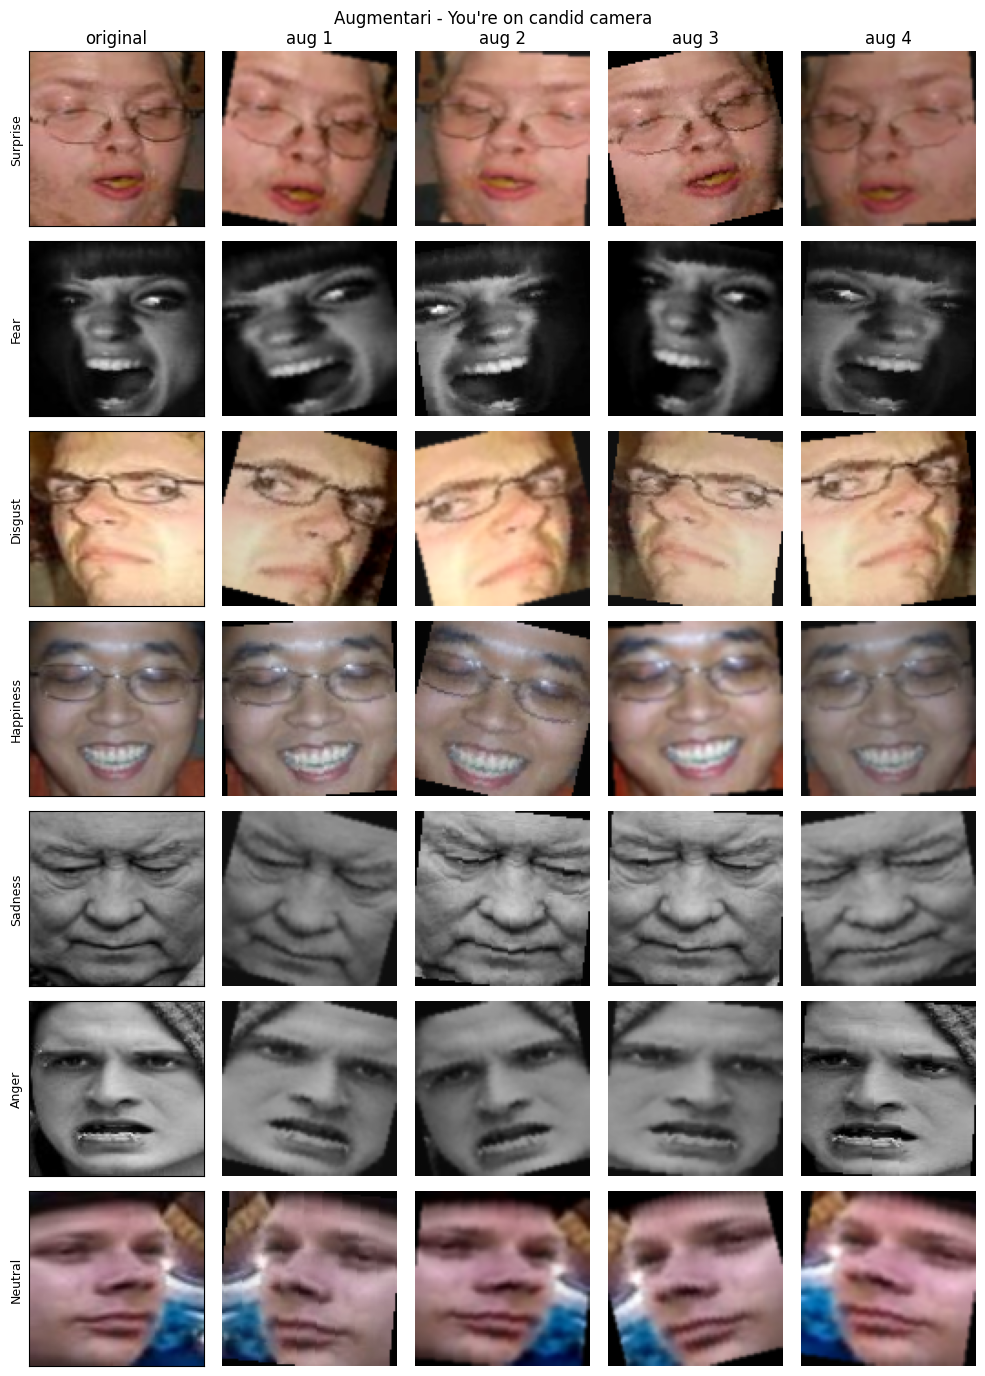

In [ ]:

def denorm(t):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

def get_label(ds, i):
    return ds.labels[i]

def visualize_augmentations(n_variants=4):
    size = cfg["img_size_cnn"]
    train_tf, eval_tf = build_transforms(size, "all")
    base = build_splits(eval_tf)[0]
  
    idx_per_class = {}
    for i in range(len(base)):
        c = get_label(base, i)
        if c not in idx_per_class:
            idx_per_class[c] = i
        if len(idx_per_class) == NUM_CLASSES:
            break

    fig, axes = plt.subplots(NUM_CLASSES, n_variants + 1,
                             figsize=(2*(n_variants+1), 2*NUM_CLASSES))
    for r, c in enumerate(sorted(idx_per_class)):
        i = idx_per_class[c]
        base.transform = eval_tf
        axes[r, 0].imshow(denorm(base[i][0]))
        axes[r, 0].set_ylabel(CLASS_NAMES[c], fontsize=9)
        axes[r, 0].set_title("original" if r == 0 else "")
        axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        base.transform = train_tf
        for k in range(1, n_variants + 1):
            axes[r, k].imshow(denorm(base[i][0]))
            if r == 0:
                axes[r, k].set_title(f"aug {k}")
            axes[r, k].axis("off")
    plt.suptitle(f"Augmentari - {cfg['name']}")
    plt.tight_layout()
    plt.savefig(RUN_DIR / "augmentari.png", dpi=120, bbox_inches="tight")
    plt.show()

visualize_augmentations()

## 5. Utilitare de antrenare si evaluare



In [ ]:
def make_loaders(train_ds, test_ds, batch_size=64, sampler=None,
                 num_workers=0):
    shuffle = sampler is None
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle,
                              sampler=sampler, num_workers=num_workers,
                              drop_last=True, pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers,
                             pin_memory=(DEVICE == "cuda"))
    return train_loader, test_loader


def freeze_bn(model):
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False


def train_one_epoch(model, loader, criterion, optimizer, freeze_bn_flag=False):
    model.train()
    if freeze_bn_flag:
        freeze_bn(model)
    run_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return run_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, labels)
        run_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return run_loss / total, correct / total


def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, scheduler=None, freeze_bn_flag=False, tag="Model"):

    history = {
        'train_loss': [], 
        'val_loss': [], 
        'test_loss': [], 
        'train_acc': [], 
        'val_acc': [], 
        'test_acc': []
    }
    
    for epoch in range(epochs):
        model.train()
        
       
        if freeze_bn_flag:
            for m in model.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()
                    
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        if scheduler:
            scheduler.step()
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
  
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                
        epoch_test_loss = test_loss / test_total
        epoch_test_acc = test_correct / test_total
        

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_test_loss)   
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_test_acc)     
        history['test_acc'].append(epoch_test_acc)
        
        print(f"[{tag}] Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.4f}")
        
    return history


In [ ]:
@torch.no_grad()
def predict(model, loader, with_labels=True):
    model.eval()
    preds, labels = [], []
    
    for batch in loader:
    
        images = batch[0].to(DEVICE, non_blocking=True)
        logits = model(images)
    
        preds.append(logits.argmax(1).cpu())
        
        if with_labels:
            labels.append(batch[1])
            
  
    preds = torch.cat(preds).numpy()
    
    if with_labels:
        return torch.cat(labels).numpy(), preds
    return preds


def report_metrics(y_true, y_pred, title=""):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_micro = f1_score(y_true, y_pred, average="micro")
    print(f"{title}: acc={acc:.4f} | F1-macro={f1_macro:.4f} | "
          f"F1-micro={f1_micro:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                digits=3, zero_division=0))
    return {"acc": acc, "f1_macro": f1_macro, "f1_micro": f1_micro}


def plot_confusion(y_true, y_pred, title="Confusion matrix", fname=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=8)
    plt.colorbar(im, fraction=0.046)
    plt.tight_layout()
    if fname:
        plt.savefig(RUN_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()


def plot_history(hist, title, fname=None):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    

    loss_key = "val_loss" if "val_loss" in hist else "test_loss"
    acc_key = "val_acc" if "val_acc" in hist else "test_acc"
    
    # Plot Loss
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist[loss_key], label="val")
    ax[0].set_title(f"Loss - {title}")
    ax[0].set_xlabel("epoca")
    ax[0].legend()

    ax[1].plot(hist["train_acc"], label="train")
    ax[1].plot(hist[acc_key], label="val")
    ax[1].set_title(f"Accuracy - {title}")
    ax[1].set_xlabel("epoca")
    ax[1].legend()
    
    if fname:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_ablation(results, metric="f1_macro", title="Ablatie", fname=None):
    '''results = dict {nume_config: hist_sau_metric_dict}.'''
    labels = list(results.keys())
    vals = [results[k][metric] if isinstance(results[k], dict)
            and metric in results[k] else results[k] for k in labels]
    fig, ax = plt.subplots(figsize=(max(5, len(labels)*1.4), 4))
    bars = ax.bar(labels, vals)
    ax.set_ylabel(metric); ax.set_title(title)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    if fname:
        plt.savefig(RUN_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()


RESULTS = {}


## 6. MLP + ablatie dropout


In [37]:
class MLP(nn.Module):
    def __init__(self, in_size, num_classes, use_dropout=True, p=0.4):
        super().__init__()
        in_feat = 3 * in_size * in_size
        drop = (lambda: nn.Dropout(p)) if use_dropout else (lambda: nn.Identity())
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_feat, 1024), nn.BatchNorm1d(1024), nn.ReLU(True), drop(),
            nn.Linear(1024, 512),    nn.BatchNorm1d(512),  nn.ReLU(True), drop(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.net(x)


In [ ]:

MLP_SIZE = cfg["img_size_mlp"]
MLP_EPOCHS = 25

train_tf, eval_tf = build_transforms(MLP_SIZE, regime="geometric")
mlp_train, mlp_test, _ = build_splits(eval_tf)
set_transform(mlp_train, train_tf)
mlp_train_loader, mlp_test_loader = make_loaders(mlp_train, mlp_test, batch_size=128)

def class_weights_from(ds):
    labels = np.array([get_label(ds, i) for i in range(len(ds))])
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts[counts == 0] = 1.0
    w = counts.sum() / (NUM_CLASSES * counts)
    return torch.tensor(w, dtype=torch.float, device=DEVICE), counts

W, COUNTS = class_weights_from(mlp_train)
print("Distributia claselor pe train:", COUNTS.astype(int))


Distributia claselor pe train: [1097  239  610 4057 1685  600 2146]


[MLP_dropout] Epoch 1/25 | Train Loss: 1.9089 Acc: 0.2571 | Test Loss: 1.7176 Acc: 0.3658
[MLP_dropout] Epoch 2/25 | Train Loss: 1.7576 Acc: 0.3577 | Test Loss: 1.5824 Acc: 0.4279
[MLP_dropout] Epoch 3/25 | Train Loss: 1.6848 Acc: 0.3820 | Test Loss: 1.6895 Acc: 0.3571
[MLP_dropout] Epoch 4/25 | Train Loss: 1.6554 Acc: 0.4000 | Test Loss: 1.6145 Acc: 0.4110
[MLP_dropout] Epoch 5/25 | Train Loss: 1.6313 Acc: 0.4113 | Test Loss: 1.6399 Acc: 0.3762
[MLP_dropout] Epoch 6/25 | Train Loss: 1.5998 Acc: 0.4276 | Test Loss: 1.5146 Acc: 0.4578
[MLP_dropout] Epoch 7/25 | Train Loss: 1.6066 Acc: 0.4280 | Test Loss: 1.5728 Acc: 0.4143
[MLP_dropout] Epoch 8/25 | Train Loss: 1.5888 Acc: 0.4359 | Test Loss: 1.5512 Acc: 0.4251
[MLP_dropout] Epoch 9/25 | Train Loss: 1.5449 Acc: 0.4448 | Test Loss: 1.4614 Acc: 0.4883
[MLP_dropout] Epoch 10/25 | Train Loss: 1.5464 Acc: 0.4565 | Test Loss: 1.4632 Acc: 0.4720
[MLP_dropout] Epoch 11/25 | Train Loss: 1.5237 Acc: 0.4568 | Test Loss: 1.4851 Acc: 0.4556
[MLP_dro

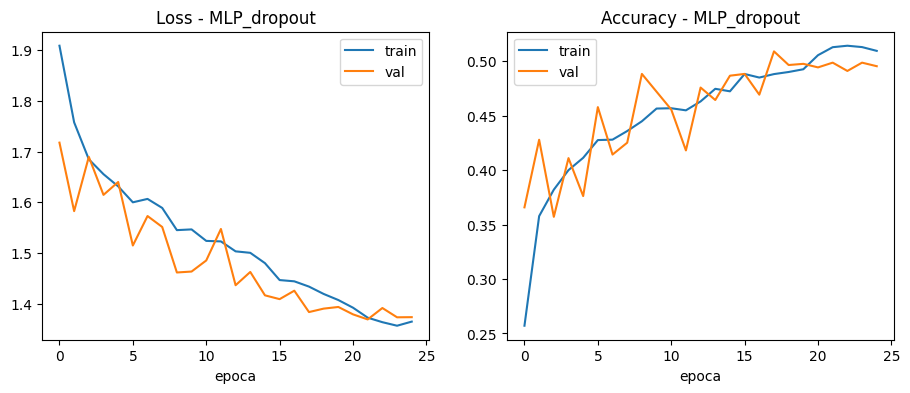

MLP_dropout: acc=0.4954 | F1-macro=0.4231 | F1-micro=0.4954
              precision    recall  f1-score   support

    Surprise      0.413     0.642     0.503       193
        Fear      0.127     0.333     0.184        42
     Disgust      0.206     0.449     0.282       107
   Happiness      0.927     0.530     0.674       715
     Sadness      0.449     0.404     0.426       297
       Anger      0.335     0.629     0.437       105
     Neutral      0.495     0.421     0.455       378

    accuracy                          0.495      1837
   macro avg      0.422     0.487     0.423      1837
weighted avg      0.613     0.495     0.523      1837



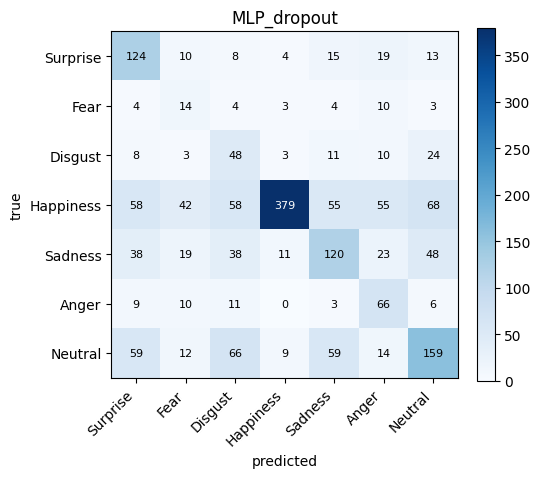

[MLP_no_dropout] Epoch 1/25 | Train Loss: 1.8536 Acc: 0.3022 | Test Loss: 1.6805 Acc: 0.3669
[MLP_no_dropout] Epoch 2/25 | Train Loss: 1.6852 Acc: 0.4085 | Test Loss: 1.6282 Acc: 0.3963
[MLP_no_dropout] Epoch 3/25 | Train Loss: 1.6259 Acc: 0.4140 | Test Loss: 1.6739 Acc: 0.3609
[MLP_no_dropout] Epoch 4/25 | Train Loss: 1.5774 Acc: 0.4344 | Test Loss: 1.5603 Acc: 0.4377
[MLP_no_dropout] Epoch 5/25 | Train Loss: 1.5500 Acc: 0.4498 | Test Loss: 1.5412 Acc: 0.4355
[MLP_no_dropout] Epoch 6/25 | Train Loss: 1.5185 Acc: 0.4657 | Test Loss: 1.4705 Acc: 0.4703
[MLP_no_dropout] Epoch 7/25 | Train Loss: 1.5120 Acc: 0.4633 | Test Loss: 1.4810 Acc: 0.4556
[MLP_no_dropout] Epoch 8/25 | Train Loss: 1.4894 Acc: 0.4730 | Test Loss: 1.4743 Acc: 0.4638
[MLP_no_dropout] Epoch 9/25 | Train Loss: 1.4487 Acc: 0.4930 | Test Loss: 1.4420 Acc: 0.4834
[MLP_no_dropout] Epoch 10/25 | Train Loss: 1.4347 Acc: 0.4991 | Test Loss: 1.4161 Acc: 0.4834
[MLP_no_dropout] Epoch 11/25 | Train Loss: 1.4160 Acc: 0.4907 | Test 

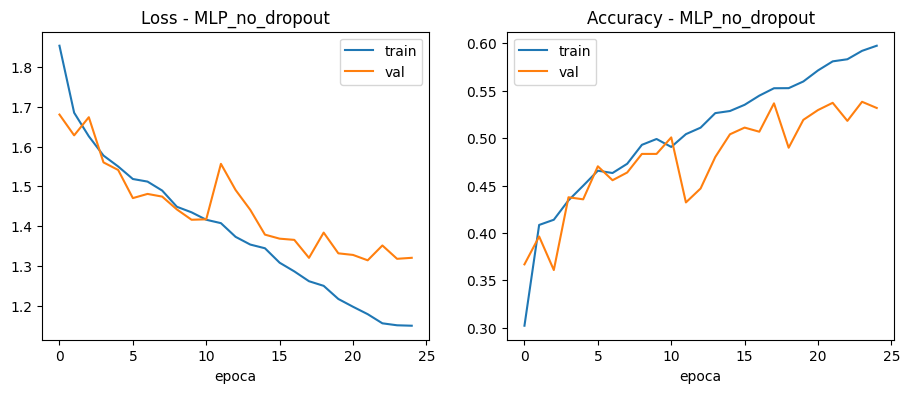

MLP_no_dropout: acc=0.5318 | F1-macro=0.4521 | F1-micro=0.5318
              precision    recall  f1-score   support

    Surprise      0.436     0.674     0.530       193
        Fear      0.130     0.286     0.179        42
     Disgust      0.229     0.439     0.301       107
   Happiness      0.936     0.550     0.693       715
     Sadness      0.503     0.495     0.499       297
       Anger      0.360     0.648     0.463       105
     Neutral      0.528     0.476     0.501       378

    accuracy                          0.532      1837
   macro avg      0.446     0.510     0.452      1837
weighted avg      0.637     0.532     0.557      1837



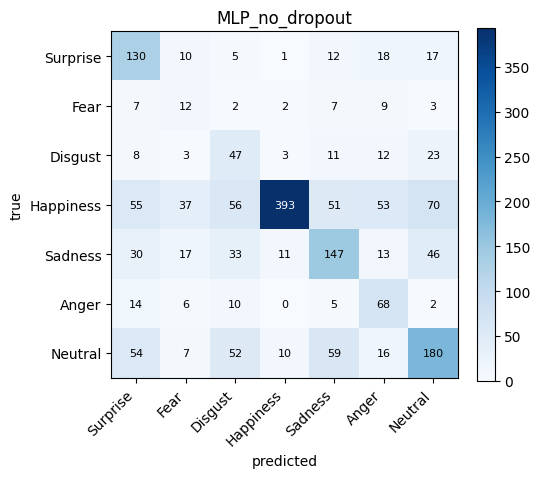

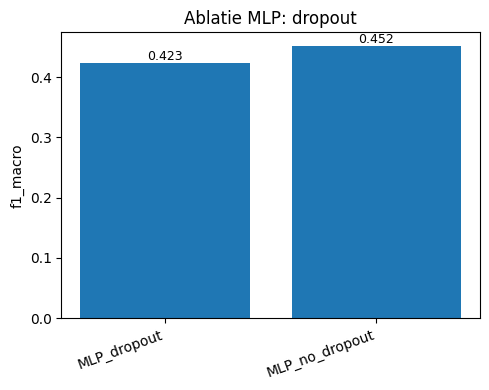

In [ ]:

mlp_hist = {}
mlp_metrics = {}
for use_drop in [True, False]:
    set_seed()
    tag = "MLP_dropout" if use_drop else "MLP_no_dropout"
    model = MLP(MLP_SIZE, NUM_CLASSES, use_dropout=use_drop).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=W)
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=MLP_EPOCHS)
    hist = train_model(model, mlp_train_loader, mlp_test_loader, crit, opt,
                       MLP_EPOCHS, scheduler=sched, tag=tag)
    plot_history(hist, tag, fname=f"{tag}_curbe.png")
    y_true, y_pred = predict(model, mlp_test_loader)
    m = report_metrics(y_true, y_pred, tag)
    plot_confusion(y_true, y_pred, tag, fname=f"{tag}_cm.png")
    mlp_hist[tag] = hist
    mlp_metrics[tag] = m
    if use_drop:
        BEST_MLP = model   

plot_ablation(mlp_metrics, "f1_macro", "Ablatie MLP: dropout",
              fname="ablatie_mlp_dropout.png")
RESULTS.update({f"{DATASET}/{k}": v for k, v in mlp_metrics.items()})


## 7. CNN + ablatii BatchNorm si augmentari


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes, first_kernel=3, use_bn=True, p_drop=0.3):
        super().__init__()
        def norm(c):
            return nn.BatchNorm2d(c) if use_bn else nn.Identity()
        bias = not use_bn
        k1, pad1 = first_kernel, first_kernel // 2
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, k1, padding=pad1, bias=bias),
            norm(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=bias),
            norm(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=bias),
            norm(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=bias),
            norm(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(True), nn.Dropout(p_drop),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:

CNN_SIZE = cfg["img_size_cnn"]
CNN_EPOCHS = 30

def run_cnn(regime="all", use_bn=True, criterion=None, sampler_fn=None,
            tag="CNN", epochs=CNN_EPOCHS):
    set_seed()
    train_tf, eval_tf = build_transforms(CNN_SIZE, regime=regime)
    tr_ds, te_ds, _ = build_splits(eval_tf)
    set_transform(tr_ds, train_tf)
    sampler = sampler_fn(tr_ds) if sampler_fn else None
    tr_loader, te_loader = make_loaders(tr_ds, te_ds, batch_size=64,
                                        sampler=sampler)
    model = CNN(NUM_CLASSES, first_kernel=cfg["first_kernel"],
                use_bn=use_bn).to(DEVICE)
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(weight=W)
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    hist = train_model(model, tr_loader, te_loader, crit, opt, epochs,
                       scheduler=sched, tag=tag)
    y_true, y_pred = predict(model, te_loader)
    m = report_metrics(y_true, y_pred, tag)
    return model, hist, m, (y_true, y_pred)


[CNN_BN] Epoch 1/30 | Train Loss: 1.8865 Acc: 0.2485 | Test Loss: 1.8098 Acc: 0.3250
[CNN_BN] Epoch 2/30 | Train Loss: 1.8716 Acc: 0.2666 | Test Loss: 1.9824 Acc: 0.2003
[CNN_BN] Epoch 3/30 | Train Loss: 1.8596 Acc: 0.2668 | Test Loss: 1.7904 Acc: 0.3032
[CNN_BN] Epoch 4/30 | Train Loss: 1.8509 Acc: 0.2921 | Test Loss: 1.8018 Acc: 0.3391
[CNN_BN] Epoch 5/30 | Train Loss: 1.8392 Acc: 0.2876 | Test Loss: 1.9704 Acc: 0.2281
[CNN_BN] Epoch 6/30 | Train Loss: 1.8274 Acc: 0.2937 | Test Loss: 1.9162 Acc: 0.2417
[CNN_BN] Epoch 7/30 | Train Loss: 1.8197 Acc: 0.2850 | Test Loss: 1.7519 Acc: 0.3533
[CNN_BN] Epoch 8/30 | Train Loss: 1.8029 Acc: 0.3044 | Test Loss: 1.7375 Acc: 0.3696
[CNN_BN] Epoch 9/30 | Train Loss: 1.7936 Acc: 0.3346 | Test Loss: 1.7705 Acc: 0.3321
[CNN_BN] Epoch 10/30 | Train Loss: 1.7695 Acc: 0.3382 | Test Loss: 1.7368 Acc: 0.3631
[CNN_BN] Epoch 11/30 | Train Loss: 1.7396 Acc: 0.3649 | Test Loss: 1.7829 Acc: 0.3446
[CNN_BN] Epoch 12/30 | Train Loss: 1.6942 Acc: 0.3898 | Test Lo

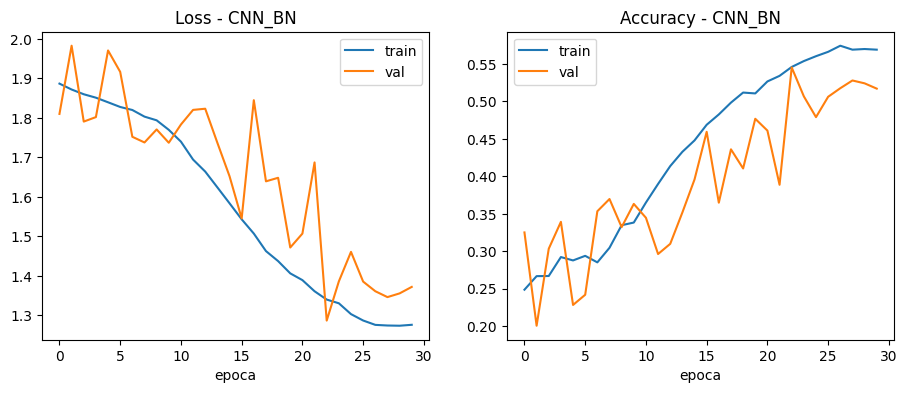

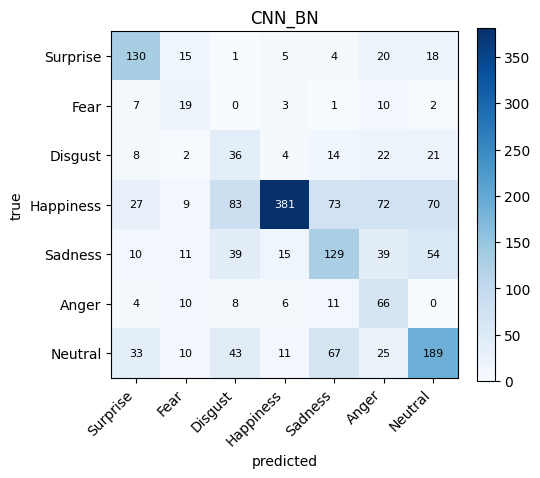

[CNN_noBN] Epoch 1/30 | Train Loss: 1.9212 Acc: 0.1744 | Test Loss: 1.8477 Acc: 0.3495
[CNN_noBN] Epoch 2/30 | Train Loss: 1.9049 Acc: 0.2525 | Test Loss: 1.9417 Acc: 0.2722
[CNN_noBN] Epoch 3/30 | Train Loss: 1.9026 Acc: 0.2561 | Test Loss: 1.8286 Acc: 0.3478
[CNN_noBN] Epoch 4/30 | Train Loss: 1.8894 Acc: 0.3001 | Test Loss: 1.8421 Acc: 0.3620
[CNN_noBN] Epoch 5/30 | Train Loss: 1.8821 Acc: 0.3118 | Test Loss: 1.8149 Acc: 0.3468
[CNN_noBN] Epoch 6/30 | Train Loss: 1.8799 Acc: 0.2927 | Test Loss: 1.8868 Acc: 0.3059
[CNN_noBN] Epoch 7/30 | Train Loss: 1.8678 Acc: 0.2939 | Test Loss: 1.8834 Acc: 0.3016
[CNN_noBN] Epoch 8/30 | Train Loss: 1.8713 Acc: 0.3139 | Test Loss: 1.9088 Acc: 0.2689
[CNN_noBN] Epoch 9/30 | Train Loss: 1.8625 Acc: 0.2998 | Test Loss: 1.9164 Acc: 0.2744
[CNN_noBN] Epoch 10/30 | Train Loss: 1.8645 Acc: 0.3026 | Test Loss: 1.8237 Acc: 0.3375
[CNN_noBN] Epoch 11/30 | Train Loss: 1.8599 Acc: 0.3110 | Test Loss: 1.8437 Acc: 0.3206
[CNN_noBN] Epoch 12/30 | Train Loss: 1.84

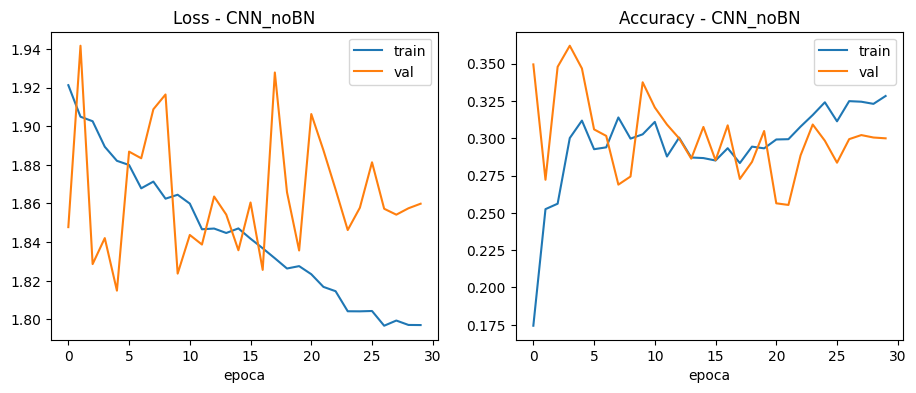

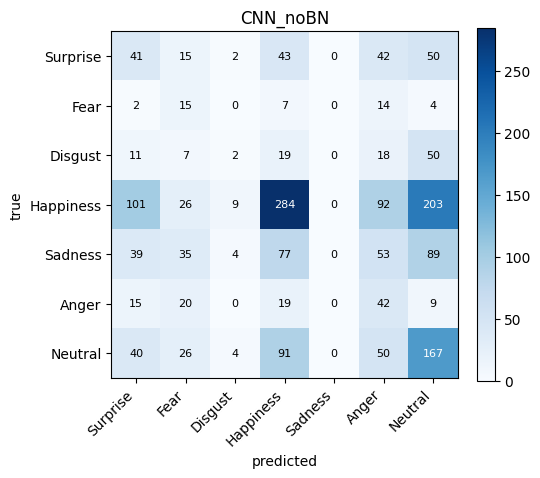

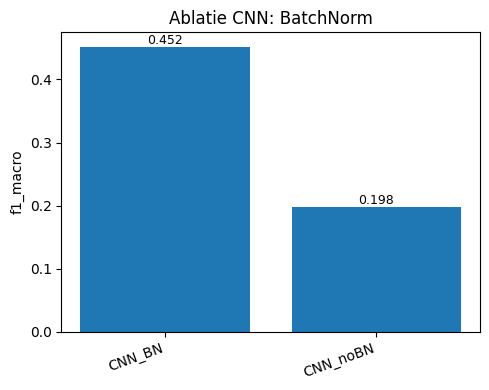

In [ ]:

cnn_bn_metrics = {}
for use_bn in [True, False]:
    tag = "CNN_BN" if use_bn else "CNN_noBN"
    model, hist, m, (yt, yp) = run_cnn(regime="all", use_bn=use_bn, tag=tag)
    plot_history(hist, tag, fname=f"{tag}_curbe.png")
    plot_confusion(yt, yp, tag, fname=f"{tag}_cm.png")
    cnn_bn_metrics[tag] = m
    if use_bn:
        BEST_CNN = model

plot_ablation(cnn_bn_metrics, "f1_macro", "Ablatie CNN: BatchNorm",
              fname="ablatie_cnn_bn.png")
RESULTS.update({f"{DATASET}/{k}": v for k, v in cnn_bn_metrics.items()})


[CNN_aug_none] Epoch 1/30 | Train Loss: 1.8634 Acc: 0.2622 | Test Loss: 1.8633 Acc: 0.2967
[CNN_aug_none] Epoch 2/30 | Train Loss: 1.8372 Acc: 0.2723 | Test Loss: 1.8949 Acc: 0.2074
[CNN_aug_none] Epoch 3/30 | Train Loss: 1.8207 Acc: 0.3111 | Test Loss: 1.9111 Acc: 0.2194
[CNN_aug_none] Epoch 4/30 | Train Loss: 1.8112 Acc: 0.3077 | Test Loss: 1.9261 Acc: 0.2493
[CNN_aug_none] Epoch 5/30 | Train Loss: 1.7805 Acc: 0.3200 | Test Loss: 1.7064 Acc: 0.3843
[CNN_aug_none] Epoch 6/30 | Train Loss: 1.7422 Acc: 0.3519 | Test Loss: 1.6392 Acc: 0.4039
[CNN_aug_none] Epoch 7/30 | Train Loss: 1.6690 Acc: 0.4096 | Test Loss: 1.5699 Acc: 0.4431
[CNN_aug_none] Epoch 8/30 | Train Loss: 1.5990 Acc: 0.4286 | Test Loss: 1.7298 Acc: 0.3832
[CNN_aug_none] Epoch 9/30 | Train Loss: 1.5365 Acc: 0.4549 | Test Loss: 2.7255 Acc: 0.1813
[CNN_aug_none] Epoch 10/30 | Train Loss: 1.4556 Acc: 0.4940 | Test Loss: 1.4143 Acc: 0.5003
[CNN_aug_none] Epoch 11/30 | Train Loss: 1.4106 Acc: 0.5082 | Test Loss: 1.4038 Acc: 0.51

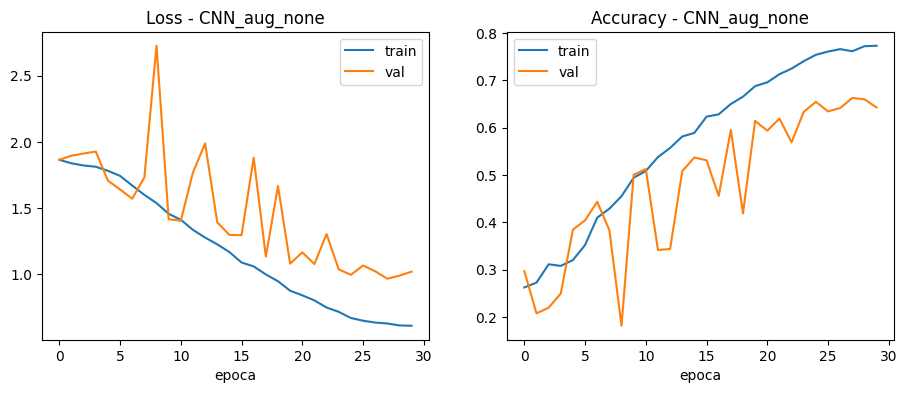

[CNN_aug_geometric] Epoch 1/30 | Train Loss: 1.8716 Acc: 0.2558 | Test Loss: 1.8585 Acc: 0.3103
[CNN_aug_geometric] Epoch 2/30 | Train Loss: 1.8647 Acc: 0.2836 | Test Loss: 1.8270 Acc: 0.2912
[CNN_aug_geometric] Epoch 3/30 | Train Loss: 1.8495 Acc: 0.2696 | Test Loss: 1.8188 Acc: 0.2760
[CNN_aug_geometric] Epoch 4/30 | Train Loss: 1.8374 Acc: 0.2977 | Test Loss: 1.7761 Acc: 0.3538
[CNN_aug_geometric] Epoch 5/30 | Train Loss: 1.8271 Acc: 0.2938 | Test Loss: 1.7864 Acc: 0.3353
[CNN_aug_geometric] Epoch 6/30 | Train Loss: 1.8176 Acc: 0.3006 | Test Loss: 1.7859 Acc: 0.2863
[CNN_aug_geometric] Epoch 7/30 | Train Loss: 1.8040 Acc: 0.2952 | Test Loss: 1.9992 Acc: 0.2613
[CNN_aug_geometric] Epoch 8/30 | Train Loss: 1.7895 Acc: 0.3061 | Test Loss: 1.7782 Acc: 0.2918
[CNN_aug_geometric] Epoch 9/30 | Train Loss: 1.7683 Acc: 0.3244 | Test Loss: 1.8218 Acc: 0.2847
[CNN_aug_geometric] Epoch 10/30 | Train Loss: 1.7418 Acc: 0.3403 | Test Loss: 1.6439 Acc: 0.4175
[CNN_aug_geometric] Epoch 11/30 | Train

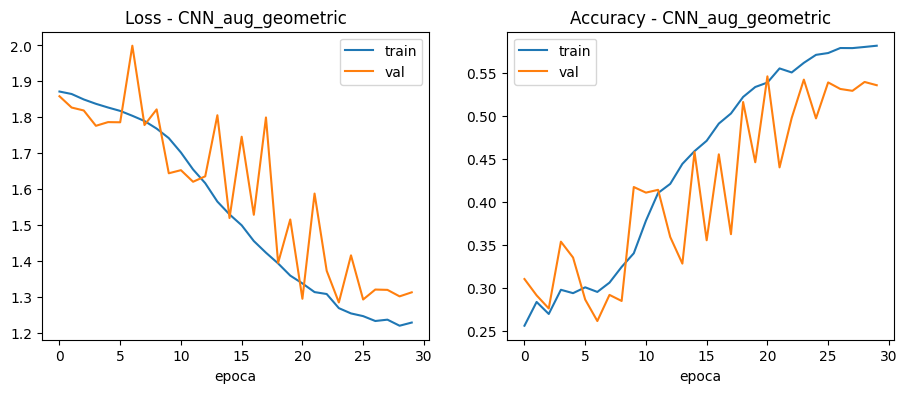

[CNN_aug_color] Epoch 1/30 | Train Loss: 1.8773 Acc: 0.2583 | Test Loss: 1.8639 Acc: 0.2972
[CNN_aug_color] Epoch 2/30 | Train Loss: 1.8568 Acc: 0.2801 | Test Loss: 1.8556 Acc: 0.2167
[CNN_aug_color] Epoch 3/30 | Train Loss: 1.8423 Acc: 0.2809 | Test Loss: 1.7806 Acc: 0.3244
[CNN_aug_color] Epoch 4/30 | Train Loss: 1.8411 Acc: 0.3026 | Test Loss: 1.8844 Acc: 0.2602
[CNN_aug_color] Epoch 5/30 | Train Loss: 1.8220 Acc: 0.3113 | Test Loss: 1.9548 Acc: 0.2515
[CNN_aug_color] Epoch 6/30 | Train Loss: 1.8007 Acc: 0.3330 | Test Loss: 1.7610 Acc: 0.3631
[CNN_aug_color] Epoch 7/30 | Train Loss: 1.7810 Acc: 0.3485 | Test Loss: 1.7267 Acc: 0.3702
[CNN_aug_color] Epoch 8/30 | Train Loss: 1.7405 Acc: 0.3750 | Test Loss: 1.8093 Acc: 0.3756
[CNN_aug_color] Epoch 9/30 | Train Loss: 1.6900 Acc: 0.4041 | Test Loss: 1.6581 Acc: 0.4126
[CNN_aug_color] Epoch 10/30 | Train Loss: 1.6150 Acc: 0.4450 | Test Loss: 2.4188 Acc: 0.1813
[CNN_aug_color] Epoch 11/30 | Train Loss: 1.5557 Acc: 0.4685 | Test Loss: 1.642

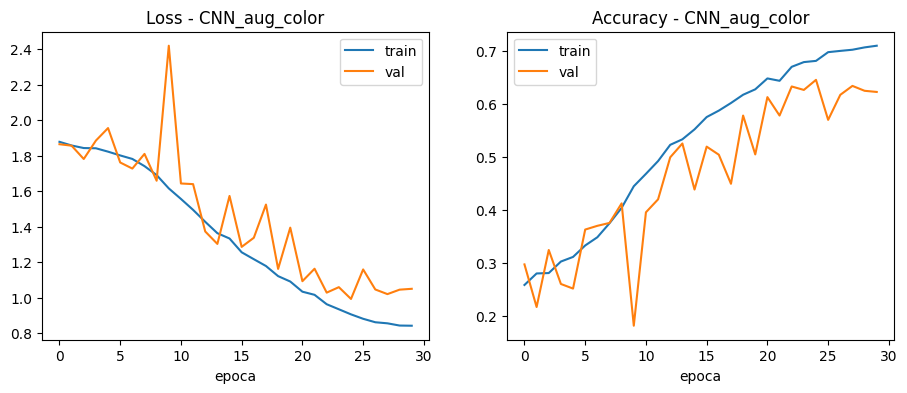

[CNN_aug_all] Epoch 1/30 | Train Loss: 1.8860 Acc: 0.2522 | Test Loss: 1.8296 Acc: 0.3293
[CNN_aug_all] Epoch 2/30 | Train Loss: 1.8726 Acc: 0.2658 | Test Loss: 1.9992 Acc: 0.2254
[CNN_aug_all] Epoch 3/30 | Train Loss: 1.8575 Acc: 0.2754 | Test Loss: 1.8287 Acc: 0.2749
[CNN_aug_all] Epoch 4/30 | Train Loss: 1.8525 Acc: 0.2816 | Test Loss: 1.8076 Acc: 0.3348
[CNN_aug_all] Epoch 5/30 | Train Loss: 1.8405 Acc: 0.2970 | Test Loss: 1.9571 Acc: 0.2510
[CNN_aug_all] Epoch 6/30 | Train Loss: 1.8262 Acc: 0.2909 | Test Loss: 1.9604 Acc: 0.2471
[CNN_aug_all] Epoch 7/30 | Train Loss: 1.8208 Acc: 0.2766 | Test Loss: 1.7717 Acc: 0.3364
[CNN_aug_all] Epoch 8/30 | Train Loss: 1.8057 Acc: 0.3150 | Test Loss: 1.7370 Acc: 0.3849
[CNN_aug_all] Epoch 9/30 | Train Loss: 1.7964 Acc: 0.3342 | Test Loss: 1.8267 Acc: 0.2624
[CNN_aug_all] Epoch 10/30 | Train Loss: 1.7688 Acc: 0.3485 | Test Loss: 1.8535 Acc: 0.2586
[CNN_aug_all] Epoch 11/30 | Train Loss: 1.7351 Acc: 0.3777 | Test Loss: 1.8583 Acc: 0.2901
[CNN_aug

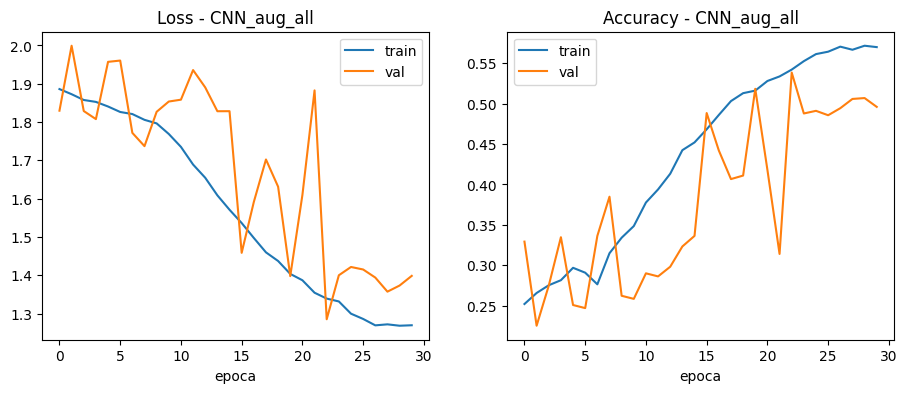

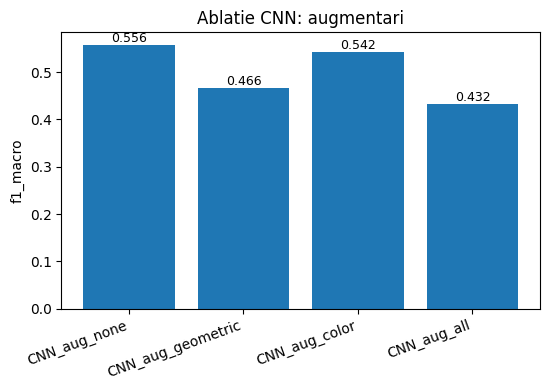

In [ ]:

aug_metrics = {}
for regime in ["none", "geometric", "color", "all"]:
    tag = f"CNN_aug_{regime}"
    model, hist, m, (yt, yp) = run_cnn(regime=regime, use_bn=True, tag=tag)
    plot_history(hist, tag, fname=f"{tag}_curbe.png")
    aug_metrics[tag] = m

plot_ablation(aug_metrics, "f1_macro", "Ablatie CNN: augmentari",
              fname="ablatie_cnn_augmentari.png")
RESULTS.update({f"{DATASET}/{k}": v for k, v in aug_metrics.items()})



## 8. Dezechilibru de clase 


In [44]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha,
                             reduction="none")
        p_t = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()


def weighted_sampler(ds):
    labels = np.array([get_label(ds, i) for i in range(len(ds))])
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts[counts == 0] = 1.0
    sample_w = (1.0 / counts)[labels]
    return WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                 num_samples=len(sample_w), replacement=True)


[baseline_CE] Epoch 1/30 | Train Loss: 1.6134 Acc: 0.3876 | Test Loss: 1.6203 Acc: 0.3756
[baseline_CE] Epoch 2/30 | Train Loss: 1.5916 Acc: 0.3960 | Test Loss: 1.5920 Acc: 0.3811
[baseline_CE] Epoch 3/30 | Train Loss: 1.5688 Acc: 0.4046 | Test Loss: 1.6021 Acc: 0.4023
[baseline_CE] Epoch 4/30 | Train Loss: 1.5511 Acc: 0.4170 | Test Loss: 1.5648 Acc: 0.4028
[baseline_CE] Epoch 5/30 | Train Loss: 1.5242 Acc: 0.4272 | Test Loss: 1.5025 Acc: 0.4224
[baseline_CE] Epoch 6/30 | Train Loss: 1.4983 Acc: 0.4376 | Test Loss: 1.5432 Acc: 0.4159
[baseline_CE] Epoch 7/30 | Train Loss: 1.4645 Acc: 0.4502 | Test Loss: 1.4534 Acc: 0.4437
[baseline_CE] Epoch 8/30 | Train Loss: 1.4074 Acc: 0.4792 | Test Loss: 1.5558 Acc: 0.4192
[baseline_CE] Epoch 9/30 | Train Loss: 1.3659 Acc: 0.4982 | Test Loss: 1.3892 Acc: 0.4888
[baseline_CE] Epoch 10/30 | Train Loss: 1.3090 Acc: 0.5237 | Test Loss: 1.6325 Acc: 0.3598
[baseline_CE] Epoch 11/30 | Train Loss: 1.2661 Acc: 0.5437 | Test Loss: 1.6152 Acc: 0.3767
[baselin

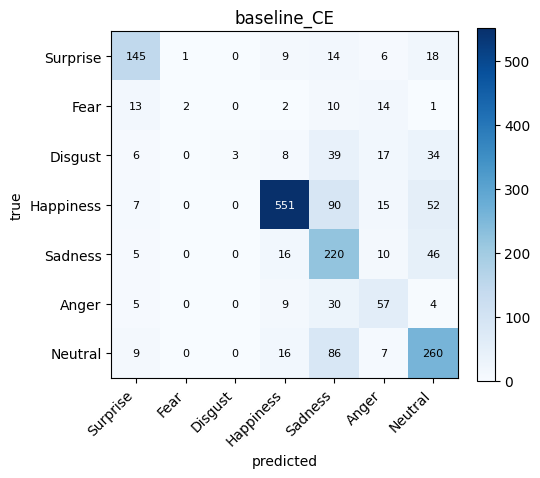

[weighted_CE] Epoch 1/30 | Train Loss: 1.8862 Acc: 0.2479 | Test Loss: 1.8483 Acc: 0.3152
[weighted_CE] Epoch 2/30 | Train Loss: 1.8722 Acc: 0.2602 | Test Loss: 2.0176 Acc: 0.2194
[weighted_CE] Epoch 3/30 | Train Loss: 1.8576 Acc: 0.2728 | Test Loss: 1.8156 Acc: 0.2956
[weighted_CE] Epoch 4/30 | Train Loss: 1.8497 Acc: 0.2863 | Test Loss: 1.8157 Acc: 0.3272
[weighted_CE] Epoch 5/30 | Train Loss: 1.8390 Acc: 0.2974 | Test Loss: 1.9934 Acc: 0.2422
[weighted_CE] Epoch 6/30 | Train Loss: 1.8272 Acc: 0.2901 | Test Loss: 1.9054 Acc: 0.2270
[weighted_CE] Epoch 7/30 | Train Loss: 1.8169 Acc: 0.2860 | Test Loss: 1.7317 Acc: 0.3620
[weighted_CE] Epoch 8/30 | Train Loss: 1.7918 Acc: 0.3233 | Test Loss: 1.7693 Acc: 0.3522
[weighted_CE] Epoch 9/30 | Train Loss: 1.7872 Acc: 0.3408 | Test Loss: 1.8026 Acc: 0.2961
[weighted_CE] Epoch 10/30 | Train Loss: 1.7530 Acc: 0.3533 | Test Loss: 1.7769 Acc: 0.3212
[weighted_CE] Epoch 11/30 | Train Loss: 1.7165 Acc: 0.3843 | Test Loss: 1.9546 Acc: 0.2635
[weighte

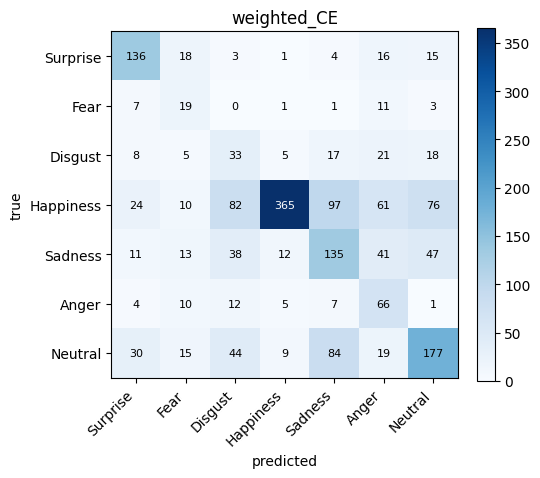

[focal_loss] Epoch 1/30 | Train Loss: 1.4127 Acc: 0.1192 | Test Loss: 1.4186 Acc: 0.1040
[focal_loss] Epoch 2/30 | Train Loss: 1.3969 Acc: 0.1196 | Test Loss: 1.4040 Acc: 0.1002
[focal_loss] Epoch 3/30 | Train Loss: 1.3829 Acc: 0.1219 | Test Loss: 1.3747 Acc: 0.1453
[focal_loss] Epoch 4/30 | Train Loss: 1.3715 Acc: 0.1345 | Test Loss: 1.3836 Acc: 0.1236
[focal_loss] Epoch 5/30 | Train Loss: 1.3568 Acc: 0.1237 | Test Loss: 1.3787 Acc: 0.0898
[focal_loss] Epoch 6/30 | Train Loss: 1.3493 Acc: 0.1227 | Test Loss: 1.3600 Acc: 0.1143
[focal_loss] Epoch 7/30 | Train Loss: 1.3404 Acc: 0.1285 | Test Loss: 1.3408 Acc: 0.1481
[focal_loss] Epoch 8/30 | Train Loss: 1.3188 Acc: 0.1396 | Test Loss: 1.3849 Acc: 0.1056
[focal_loss] Epoch 9/30 | Train Loss: 1.3102 Acc: 0.1540 | Test Loss: 1.2961 Acc: 0.1187
[focal_loss] Epoch 10/30 | Train Loss: 1.2881 Acc: 0.1539 | Test Loss: 1.3092 Acc: 0.1720
[focal_loss] Epoch 11/30 | Train Loss: 1.2669 Acc: 0.1869 | Test Loss: 1.2645 Acc: 0.1682
[focal_loss] Epoch 

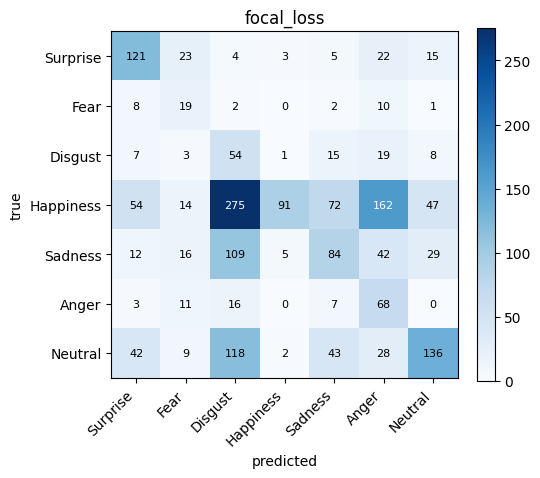

[weighted_samp] Epoch 1/30 | Train Loss: 1.8634 Acc: 0.2342 | Test Loss: 1.8016 Acc: 0.3375
[weighted_samp] Epoch 2/30 | Train Loss: 1.8484 Acc: 0.2479 | Test Loss: 1.8511 Acc: 0.2852
[weighted_samp] Epoch 3/30 | Train Loss: 1.8219 Acc: 0.2630 | Test Loss: 1.8264 Acc: 0.3277
[weighted_samp] Epoch 4/30 | Train Loss: 1.7967 Acc: 0.2801 | Test Loss: 1.8220 Acc: 0.3070
[weighted_samp] Epoch 5/30 | Train Loss: 1.7487 Acc: 0.3104 | Test Loss: 1.9563 Acc: 0.2618
[weighted_samp] Epoch 6/30 | Train Loss: 1.7272 Acc: 0.3230 | Test Loss: 1.7724 Acc: 0.3174
[weighted_samp] Epoch 7/30 | Train Loss: 1.6499 Acc: 0.3680 | Test Loss: 1.8086 Acc: 0.3424
[weighted_samp] Epoch 8/30 | Train Loss: 1.5741 Acc: 0.3951 | Test Loss: 2.1567 Acc: 0.2553
[weighted_samp] Epoch 9/30 | Train Loss: 1.5160 Acc: 0.4241 | Test Loss: 1.8906 Acc: 0.3239
[weighted_samp] Epoch 10/30 | Train Loss: 1.4515 Acc: 0.4529 | Test Loss: 1.5940 Acc: 0.4447
[weighted_samp] Epoch 11/30 | Train Loss: 1.3937 Acc: 0.4778 | Test Loss: 1.580

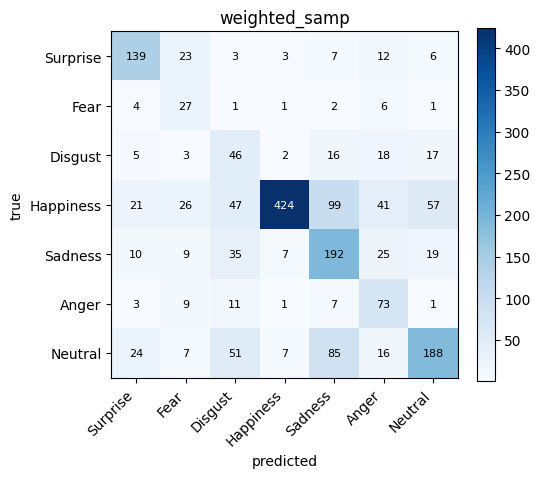

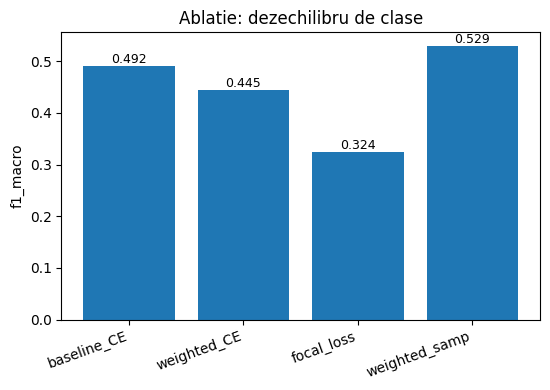

In [ ]:

imbalance_metrics = {}

configs = {
    "baseline_CE":   dict(criterion=nn.CrossEntropyLoss(), sampler_fn=None),
    "weighted_CE":   dict(criterion=nn.CrossEntropyLoss(weight=W), sampler_fn=None),
    "focal_loss":    dict(criterion=FocalLoss(alpha=W, gamma=2.0), sampler_fn=None),
    "weighted_samp": dict(criterion=nn.CrossEntropyLoss(),
                          sampler_fn=weighted_sampler),
}
for tag, kw in configs.items():
    model, hist, m, (yt, yp) = run_cnn(regime="all", use_bn=True, tag=tag, **kw)
    plot_confusion(yt, yp, tag, fname=f"imbalance_{tag}_cm.png")
    imbalance_metrics[tag] = m

plot_ablation(imbalance_metrics, "f1_macro", "Ablatie: dezechilibru de clase",
              fname="ablatie_dezechilibru.png")
RESULTS.update({f"{DATASET}/imb_{k}": v for k, v in imbalance_metrics.items()})


## 9. Finetuning + ablatie warmup 


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def finetune_transforms(train=True):
    norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), norm])
    return transforms.Compose([transforms.Resize((224, 224)),
                               transforms.ToTensor(), norm])


def build_pretrained(arch="resnet18", freeze_backbone=True):
    if arch == "resnet18":
        m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        in_f = m.fc.in_features
        m.fc = nn.Linear(in_f, NUM_CLASSES)
        head = m.fc
    else:  
        m = tv_models.mobilenet_v2(
            weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_f = m.classifier[-1].in_features
        m.classifier[-1] = nn.Linear(in_f, NUM_CLASSES)
        head = m.classifier[-1]
    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
        for p in head.parameters():
            p.requires_grad = True
    return m.to(DEVICE)


In [ ]:
FT_EPOCHS = 20
FT_WARMUP = 3

def run_finetune(arch="resnet18", use_warmup=True, tag="ft"):
    set_seed()
    tr_ds, te_ds, remote_ds = build_splits(finetune_transforms(train=False))
    set_transform(tr_ds, finetune_transforms(train=True))
    tr_loader, te_loader = make_loaders(tr_ds, te_ds, batch_size=64)

    model = build_pretrained(arch, freeze_backbone=True)
    crit = nn.CrossEntropyLoss(weight=W)
    params = filter(lambda p: p.requires_grad, model.parameters())
    opt = optim.Adam(params, lr=1e-3, weight_decay=1e-4)

    if use_warmup:
        warm = LambdaLR(opt, lr_lambda=lambda e: (e + 1) / FT_WARMUP)
        cos = CosineAnnealingLR(opt, T_max=max(1, FT_EPOCHS - FT_WARMUP))
        sched = SequentialLR(opt, [warm, cos], milestones=[FT_WARMUP])
    else:
        sched = CosineAnnealingLR(opt, T_max=FT_EPOCHS)

    hist = train_model(model, tr_loader, te_loader, crit, opt, FT_EPOCHS,
                       scheduler=sched, freeze_bn_flag=True, tag=tag)
    y_true, y_pred = predict(model, te_loader)
    m = report_metrics(y_true, y_pred, tag)
    return model, hist, m, (y_true, y_pred), remote_ds


[ResNet18_warmup] Epoch 1/20 | Train Loss: 1.8474 Acc: 0.2985 | Val Loss: 1.7620 Acc: 0.3478
[ResNet18_warmup] Epoch 2/20 | Train Loss: 1.6514 Acc: 0.4230 | Val Loss: 1.5807 Acc: 0.4556


c:\Users\miner\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[ResNet18_warmup] Epoch 3/20 | Train Loss: 1.5460 Acc: 0.4600 | Val Loss: 1.6963 Acc: 0.3435
[ResNet18_warmup] Epoch 4/20 | Train Loss: 1.4737 Acc: 0.4861 | Val Loss: 1.5633 Acc: 0.4371
[ResNet18_warmup] Epoch 5/20 | Train Loss: 1.4264 Acc: 0.4992 | Val Loss: 1.4627 Acc: 0.4725
[ResNet18_warmup] Epoch 6/20 | Train Loss: 1.3958 Acc: 0.5133 | Val Loss: 1.4459 Acc: 0.4965
[ResNet18_warmup] Epoch 7/20 | Train Loss: 1.3765 Acc: 0.5154 | Val Loss: 1.4056 Acc: 0.4997
[ResNet18_warmup] Epoch 8/20 | Train Loss: 1.3602 Acc: 0.5196 | Val Loss: 1.4314 Acc: 0.4905
[ResNet18_warmup] Epoch 9/20 | Train Loss: 1.3471 Acc: 0.5259 | Val Loss: 1.5148 Acc: 0.4682
[ResNet18_warmup] Epoch 10/20 | Train Loss: 1.3317 Acc: 0.5242 | Val Loss: 1.4628 Acc: 0.4763
[ResNet18_warmup] Epoch 11/20 | Train Loss: 1.3179 Acc: 0.5368 | Val Loss: 1.4840 Acc: 0.4709
[ResNet18_warmup] Epoch 12/20 | Train Loss: 1.3083 Acc: 0.5390 | Val Loss: 1.5255 Acc: 0.4317
[ResNet18_warmup] Epoch 13/20 | Train Loss: 1.2995 Acc: 0.5344 | Va

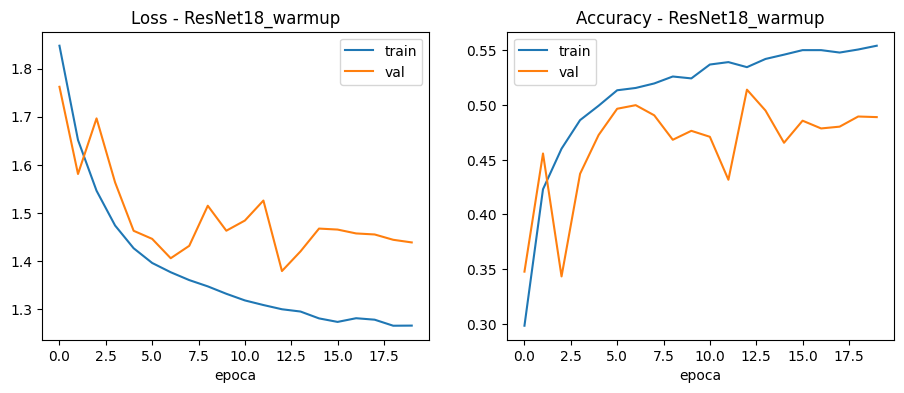

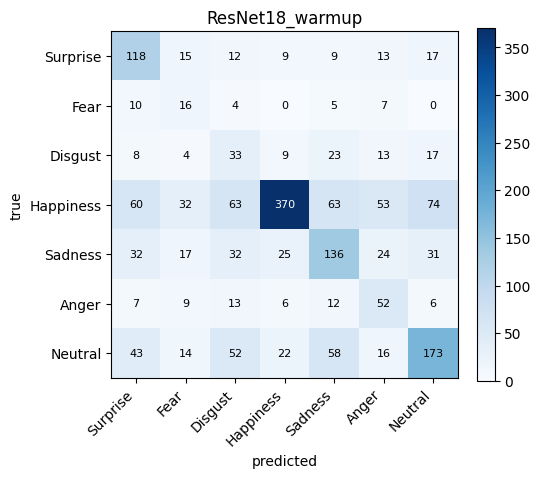

[ResNet18_no_warmup] Epoch 1/20 | Train Loss: 1.7499 Acc: 0.3516 | Val Loss: 1.5755 Acc: 0.4355
[ResNet18_no_warmup] Epoch 2/20 | Train Loss: 1.5459 Acc: 0.4572 | Val Loss: 1.5210 Acc: 0.4616
[ResNet18_no_warmup] Epoch 3/20 | Train Loss: 1.4806 Acc: 0.4814 | Val Loss: 1.6571 Acc: 0.3691
[ResNet18_no_warmup] Epoch 4/20 | Train Loss: 1.4350 Acc: 0.4993 | Val Loss: 1.5391 Acc: 0.4469
[ResNet18_no_warmup] Epoch 5/20 | Train Loss: 1.4002 Acc: 0.5059 | Val Loss: 1.4412 Acc: 0.4839
[ResNet18_no_warmup] Epoch 6/20 | Train Loss: 1.3768 Acc: 0.5190 | Val Loss: 1.4310 Acc: 0.5035
[ResNet18_no_warmup] Epoch 7/20 | Train Loss: 1.3620 Acc: 0.5208 | Val Loss: 1.4079 Acc: 0.4954
[ResNet18_no_warmup] Epoch 8/20 | Train Loss: 1.3474 Acc: 0.5236 | Val Loss: 1.4354 Acc: 0.4878
[ResNet18_no_warmup] Epoch 9/20 | Train Loss: 1.3389 Acc: 0.5292 | Val Loss: 1.4837 Acc: 0.4785
[ResNet18_no_warmup] Epoch 10/20 | Train Loss: 1.3247 Acc: 0.5272 | Val Loss: 1.4668 Acc: 0.4747
[ResNet18_no_warmup] Epoch 11/20 | Trai

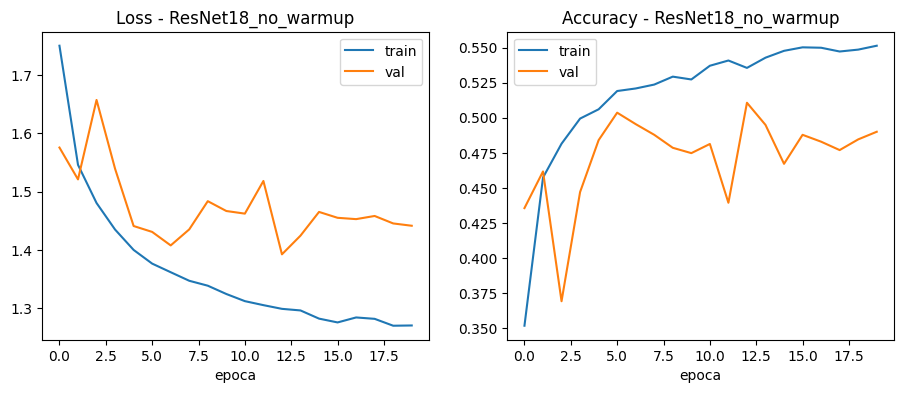

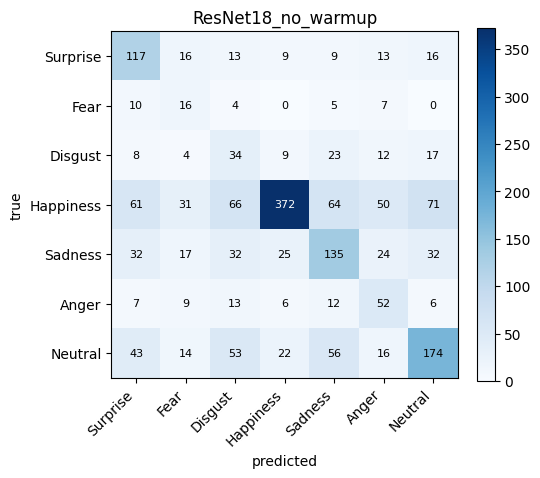

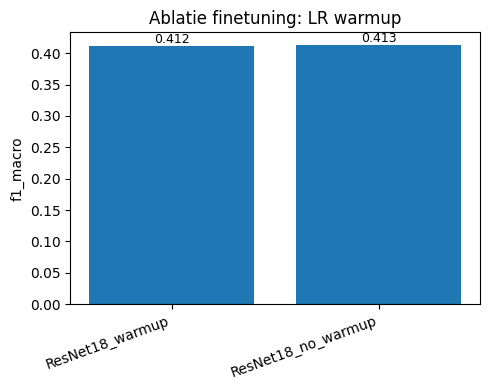

In [ ]:

ft_metrics = {}
for use_warmup in [True, False]:
    tag = "ResNet18_warmup" if use_warmup else "ResNet18_no_warmup"
    model, hist, m, (yt, yp), remote_ds = run_finetune("resnet18", use_warmup, tag)
    plot_history(hist, tag, fname=f"{tag}_curbe.png")
    plot_confusion(yt, yp, tag, fname=f"{tag}_cm.png")
    ft_metrics[tag] = m
    if use_warmup:
        BEST_FT, BEST_FT_REMOTE = model, remote_ds

plot_ablation(ft_metrics, "f1_macro", "Ablatie finetuning: LR warmup",
              fname="ablatie_warmup.png")
RESULTS.update({f"{DATASET}/{k}": v for k, v in ft_metrics.items()})


## 10. Submisie Kaggle


In [ ]:
def make_submission(model, remote_ds, fname="submission.csv"):
    loader = DataLoader(remote_ds, batch_size=64, shuffle=False, num_workers=0)
    preds = predict(model, loader, with_labels=False)
    ids = remote_ds.ids   

    if DATASET == "skin":
      
        idx2name = {i: c for i, c in enumerate(CLASS_NAMES)}
        out = pd.DataFrame({"imagine": ids,
                            "diagnostic": [idx2name[p] for p in preds]})
    else:
 
        out = pd.DataFrame({"id": ids, "label": preds + 1})

    path = RUN_DIR / fname
    out.to_csv(path, index=False)
    print("Scris:", path, "| randuri:", len(out))
    return out

sub = make_submission(BEST_FT, BEST_FT_REMOTE, fname=f"submission_{DATASET}_resnet18.csv")
sub.head()


Scris: outputs\emotions\submission_emotions_resnet18.csv | randuri: 3068


,id,label
0,test_0789_aligned.jpg,1
1,test_0200_aligned.jpg,3
2,test_1342_aligned.jpg,1
3,test_0125_aligned.jpg,4
4,test_1933_aligned.jpg,7
